In [1]:
"""
CST8506 Assignment 1: Wine Quality Classification
Author: Peng Wang
Student Number: 041107730

Explores Wine Quality dataset from UCI ML Repository.
Reduces dimensionality via PCA and LDA, then classifies using
kNN, Random Forest, SVM, Logistic Regression, and MLP.
Compares results before and after dimensionality reduction
following the CRISP-DM methodology.
"""

# 导入操作系统和路径模块
# Import os and path modules
import os
from pathlib import Path

# 导入数值计算和数据处理库
# Import numerical computing and data processing libraries
import numpy as np
import pandas as pd

# 导入绘图库
# Import plotting library
import matplotlib.pyplot as plt

# 导入数据集加载工具
# Import dataset loading utility
from sklearn.datasets import load_wine

# 导入数据预处理工具
# Import data preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 导入降维方法
# Import dimensionality reduction methods
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 导入分类器
# Import classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# 导入评估指标
# Import evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 导入表格格式化工具
# Import table formatting utility
from tabulate import tabulate

# 导入警告模块以抑制收敛警告
# Import warnings module to suppress convergence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 固定随机种子以确保结果可复现
# Fixed random seed for reproducibility
RANDOM_STATE = 42

# 80-20 训练集-测试集划分
# 80-20 train-test split ratio
TEST_SIZE = 0.2

# 保留95%的方差用于PCA
# Retain 95% of variance for PCA
VARIANCE_THRESHOLD = 0.95

# 输出图片目录
# Output images directory
OUTPUT_DIR = Path('assignment1_images')

# 图片分辨率
# Image resolution
IMAGE_DPI = 150

# 分隔线宽度
# Divider line width
LINE_WIDTH = 60

In [3]:
# ============================================================
# 环境设置
# Environment Setup
# ============================================================
# 创建输出目录
# Create output directory
OUTPUT_DIR.mkdir(exist_ok=True)

# 设置numpy的随机种子
# Set numpy random seed
np.random.seed(RANDOM_STATE)

# 设置pandas显示选项，避免输出被截断
# Set pandas display options to avoid truncated output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

print("=" * LINE_WIDTH)
print("CST8506 Assignment 1: Wine Quality Classification")
print("Author: Peng Wang | Student Number: 041107730")
print("=" * LINE_WIDTH)
print()

CST8506 Assignment 1: Wine Quality Classification
Author: Peng Wang | Student Number: 041107730



In [4]:
# ============================================================
# 步骤 1：数据理解 - 加载Wine Quality数据集
# Step 1: Data Understanding - Load Wine Quality Dataset
# ============================================================
print("=" * LINE_WIDTH)
print("Step 1: Data Understanding - Load Wine Quality Dataset")
print("=" * LINE_WIDTH)

# 使用sklearn的load_wine()函数加载数据集
# 原因：UCI的Wine Quality数据集已内置在sklearn中，方便加载
# Use sklearn's load_wine() to load the dataset
# Reason: UCI Wine Quality dataset is built into sklearn for easy loading
wine = load_wine()

# X是特征矩阵，y是目标变量
# X is the feature matrix, y is the target variable
X = wine.data
y = wine.target

# 创建DataFrame方便数据分析
# Create DataFrame for easier data analysis
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print(f"Dataset: Wine (sklearn built-in)")
print(f"Source: UCI Machine Learning Repository")
print(f"Number of instances: {X.shape[0]}")
print(f"Number of attributes: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class labels: {np.unique(y).tolist()}")
print(f"Target names: {wine.target_names.tolist()}")
print()

Step 1: Data Understanding - Load Wine Quality Dataset
Dataset: Wine (sklearn built-in)
Source: UCI Machine Learning Repository
Number of instances: 178
Number of attributes: 13
Number of classes: 3
Class labels: [0, 1, 2]
Target names: ['class_0', 'class_1', 'class_2']



In [5]:
# ============================================================
# 步骤 2：数据理解 - 数据集统计信息
# Step 2: Data Understanding - Dataset Statistics
# ============================================================
print("=" * LINE_WIDTH)
print("Step 2: Data Understanding - Dataset Statistics")
print("=" * LINE_WIDTH)

# 打印特征名称列表
# Print feature names list
print("Attribute names:")
for i, name in enumerate(wine.feature_names, 1):
    print(f"  {i}. {name}")

# 类别分布
# Class distribution
print(f"\nClass distribution:")
for cls in np.unique(y):
    count = np.sum(y == cls)
    print(f"  Class {cls} ({wine.target_names[cls]}): {count} instances ({count/len(y)*100:.1f}%)")

# 打印前5行数据
# Print first 5 rows
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

# 打印描述性统计
# Print descriptive statistics
print(f"\nDescriptive statistics:")
print(df.describe())
print()

Step 2: Data Understanding - Dataset Statistics
Attribute names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Class distribution:
  Class 0 (class_0): 59 instances (33.1%)
  Class 1 (class_1): 71 instances (39.9%)
  Class 2 (class_2): 48 instances (27.0%)

First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  od280/od315_of_diluted_wines  proline  target
0    14.23        1.71  2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64  1.04                          3.92   1065.0       0
1    13.20        1.78  2.14               11.2      100.0           2.65        2.76                  0.26             1.28     

In [6]:
# ============================================================
# 步骤 3：数据理解 - 缺失值和数据类型检查
# Step 3: Data Understanding - Missing Values and Data Types
# ============================================================
print("=" * LINE_WIDTH)
print("Step 3: Data Understanding - Missing Values & Data Types")
print("=" * LINE_WIDTH)

# 检查缺失值
# Check for missing values
print("Missing values per attribute:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# 检查数据类型
# Check data types
print(f"\nData types:")
print(df.dtypes)
print()

Step 3: Data Understanding - Missing Values & Data Types
Missing values per attribute:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Total missing values: 0

Data types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity           

In [7]:
# ============================================================
# 步骤 4：数据准备 - 划分训练集和测试集
# Step 4: Data Preparation - Split Train and Test Sets
# ============================================================
print("=" * LINE_WIDTH)
print("Step 4: Data Preparation - Train/Test Split")
print("=" * LINE_WIDTH)

# 使用stratify确保各类别比例在训练集和测试集中相同
# Use stratify to ensure same class proportions in train and test sets
# 原因：避免某个类别在测试集中被过多/过少采样
# Reason: Avoid over/under-sampling of any class in the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} instances")
print(f"Test set size: {X_test.shape[0]} instances")
print(f"Train/Test ratio: {1-TEST_SIZE:.0%}/{TEST_SIZE:.0%}")

# 验证分层抽样
# Verify stratified sampling
print(f"\nClass distribution in training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"  Class {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nClass distribution in test set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    print(f"  Class {cls}: {count} ({count/len(y_test)*100:.1f}%)")
print()

Step 4: Data Preparation - Train/Test Split
Training set size: 142 instances
Test set size: 36 instances
Train/Test ratio: 80%/20%

Class distribution in training set:
  Class 0: 47 (33.1%)
  Class 1: 57 (40.1%)
  Class 2: 38 (26.8%)

Class distribution in test set:
  Class 0: 12 (33.3%)
  Class 1: 14 (38.9%)
  Class 2: 10 (27.8%)



In [8]:
# ============================================================
# 步骤 5：数据准备 - 标准化数据
# Step 5: Data Preparation - Standardize Data
# ============================================================
print("=" * LINE_WIDTH)
print("Step 5: Data Preparation - Standardize Data")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：标准化 (StandardScaler)
# Concept: Standardization (StandardScaler)
# ================================================================
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   将每个特征转换为均值为0、标准差为1的分布
#   Transform each feature to have mean=0 and std=1
#
# 公式 / Formula:
#   z = (x - μ) / σ，其中μ是均值，σ是标准差
#   z = (x - μ) / σ, where μ is mean and σ is standard deviation
#
# 举例 / Example:
#   酒精含量原始值：12.5, μ=13.0, σ=0.8
#   标准化后：(12.5-13.0)/0.8 = -0.625
#
# 优点 / Advantages:
#   - 消除特征尺度差异，让所有特征在同一量级
#   - kNN、SVM、MLP等算法对特征尺度敏感，必须标准化
# ================================================================
scaler = StandardScaler()

# 对训练集进行拟合和转换
# Fit and transform training set
X_train_scaled = scaler.fit_transform(X_train)

# 对测试集只进行转换，使用训练集的均值和标准差
# Only transform test set using training set's mean and std
# 原因：避免数据泄露（test set不应参与fit过程）
# Reason: Prevent data leakage (test set must not participate in fitting)
X_test_scaled = scaler.transform(X_test)

print("Data standardized successfully")
print(f"Mean of scaled training data: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training data: {X_train_scaled.std():.6f}")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print()

Step 5: Data Preparation - Standardize Data
Data standardized successfully
Mean of scaled training data: 0.000000
Std of scaled training data: 1.000000
Shape of X_train_scaled: (142, 13)
Shape of X_test_scaled: (36, 13)



In [9]:
# ============================================================
# 步骤 6：数据准备 - 应用PCA降维
# Step 6: Data Preparation - Apply PCA
# ============================================================
print("=" * LINE_WIDTH)
print("Step 6: Data Preparation - Apply PCA")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：主成分分析 (PCA)
# Concept: Principal Component Analysis (PCA)
# ================================================================
#
# -------- 术语解释 / Terminology --------
#
# 【主成分 Principal Component】
#   数据方差最大方向上的新坐标轴
#   New coordinate axes in the direction of maximum data variance
#
# 【解释方差比 Explained Variance Ratio】
#   每个主成分解释的数据方差占总方差的百分比
#   Percentage of total variance explained by each principal component
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   无监督降维，找到方差最大的方向投影数据
#   Unsupervised dimensionality reduction, projects data onto directions of maximum variance
#
# 公式 / Formula:
#   PC_k = w_k^T * X，其中w_k是第k个特征向量
#   PC_k = w_k^T * X, where w_k is the k-th eigenvector
#
# 举例 / Example:
#   13个特征 → PCA保留95%方差 → 可能只需8-10个主成分
#
# 优点 / Advantages:
#   - 减少特征数量，降低计算成本
#   - 消除多重共线性
# ================================================================

# 首先运行完整PCA分析所有主成分
# First run full PCA to analyze all components
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled)

# 获取解释方差比和累积方差
# Get explained variance ratios and cumulative variance
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio for each component:")
for i, var in enumerate(explained_var, 1):
    print(f"  PC{i}: {var:.4f} ({var*100:.2f}%)")

print("\nCumulative Explained Variance Ratios:")
for i, cum_var in enumerate(cumulative_var, 1):
    print(f"  PC1-PC{i}: {cum_var:.4f} ({cum_var*100:.2f}%)")

# 找到达到95%方差所需的最少主成分数量
# Find minimum number of components needed for 95% variance
d_pca = np.argmax(cumulative_var >= VARIANCE_THRESHOLD) + 1
print(f"\nOptimal number of components (d) for {VARIANCE_THRESHOLD*100:.0f}% variance: {d_pca}")
print(f"Variance explained by {d_pca} components: {cumulative_var[d_pca-1]:.4f} ({cumulative_var[d_pca-1]*100:.2f}%)")

# 使用最佳d重新运行PCA
# Re-run PCA with optimal d
pca = PCA(n_components=d_pca)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nDimensionality reduction: {X_train_scaled.shape[1]} -> {d_pca}")
print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print()

Step 6: Data Preparation - Apply PCA
Explained Variance Ratio for each component:
  PC1: 0.3579 (35.79%)
  PC2: 0.1927 (19.27%)
  PC3: 0.1102 (11.02%)
  PC4: 0.0727 (7.27%)
  PC5: 0.0672 (6.72%)
  PC6: 0.0513 (5.13%)
  PC7: 0.0438 (4.38%)
  PC8: 0.0250 (2.50%)
  PC9: 0.0228 (2.28%)
  PC10: 0.0188 (1.88%)
  PC11: 0.0178 (1.78%)
  PC12: 0.0126 (1.26%)
  PC13: 0.0072 (0.72%)

Cumulative Explained Variance Ratios:
  PC1-PC1: 0.3579 (35.79%)
  PC1-PC2: 0.5506 (55.06%)
  PC1-PC3: 0.6608 (66.08%)
  PC1-PC4: 0.7335 (73.35%)
  PC1-PC5: 0.8008 (80.08%)
  PC1-PC6: 0.8521 (85.21%)
  PC1-PC7: 0.8959 (89.59%)
  PC1-PC8: 0.9209 (92.09%)
  PC1-PC9: 0.9437 (94.37%)
  PC1-PC10: 0.9624 (96.24%)
  PC1-PC11: 0.9803 (98.03%)
  PC1-PC12: 0.9928 (99.28%)
  PC1-PC13: 1.0000 (100.00%)

Optimal number of components (d) for 95% variance: 10
Variance explained by 10 components: 0.9624 (96.24%)

Dimensionality reduction: 13 -> 10
Shape of X_train_pca: (142, 10)
Shape of X_test_pca: (36, 10)



In [10]:
# ============================================================
# 步骤 7：数据准备 - 应用LDA降维
# Step 7: Data Preparation - Apply LDA
# ============================================================
print("=" * LINE_WIDTH)
print("Step 7: Data Preparation - Apply LDA")
print("=" * LINE_WIDTH)

# ================================================================
# 概念：线性判别分析 (LDA)
# Concept: Linear Discriminant Analysis (LDA)
# ================================================================
#
# -------- 术语解释 / Terminology --------
#
# 【类间距离 Between-class Distance】
#   不同类别中心之间的距离
#   Distance between class centers
#
# 【类内距离 Within-class Distance】
#   同一类别内样本之间的距离
#   Distance between samples within the same class
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   有监督降维，最大化类间距离同时最小化类内距离
#   Supervised dimensionality reduction, maximizes between-class distance while minimizing within-class distance
#
# 公式 / Formula:
#   J(w) = (w^T * S_B * w) / (w^T * S_W * w)
#   S_B是类间散度矩阵，S_W是类内散度矩阵
#
# 举例 / Example:
#   3个类别 → LDA最多保留 n_classes-1=2 个成分
#
# 优点 / Advantages:
#   - 利用类别信息，降维后数据更有利于分类
#   - 通常比PCA在分类任务上表现更好
# ================================================================

# LDA最多保留 (n_classes - 1) 个成分
# LDA retains at most (n_classes - 1) components
n_classes = len(np.unique(y))
d_lda = n_classes - 1

print(f"Number of classes: {n_classes}")
print(f"Number of LDA components (n_classes - 1): {d_lda}")

# 创建LDA对象并拟合转换
# Create LDA object and fit-transform
lda = LinearDiscriminantAnalysis(n_components=d_lda)

# 注意LDA是有监督的，需要传入y_train
# Note: LDA is supervised, requires y_train
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print(f"Dimensionality reduction: {X_train_scaled.shape[1]} -> {d_lda}")
print(f"Explained variance ratio by LDA: {lda.explained_variance_ratio_}")
print(f"Shape of X_train_lda: {X_train_lda.shape}")
print(f"Shape of X_test_lda: {X_test_lda.shape}")
print()

Step 7: Data Preparation - Apply LDA
Number of classes: 3
Number of LDA components (n_classes - 1): 2
Dimensionality reduction: 13 -> 2
Explained variance ratio by LDA: [0.69352994 0.30647006]
Shape of X_train_lda: (142, 2)
Shape of X_test_lda: (36, 2)



Step 8: Scree Plot and Cumulative Scree Plot


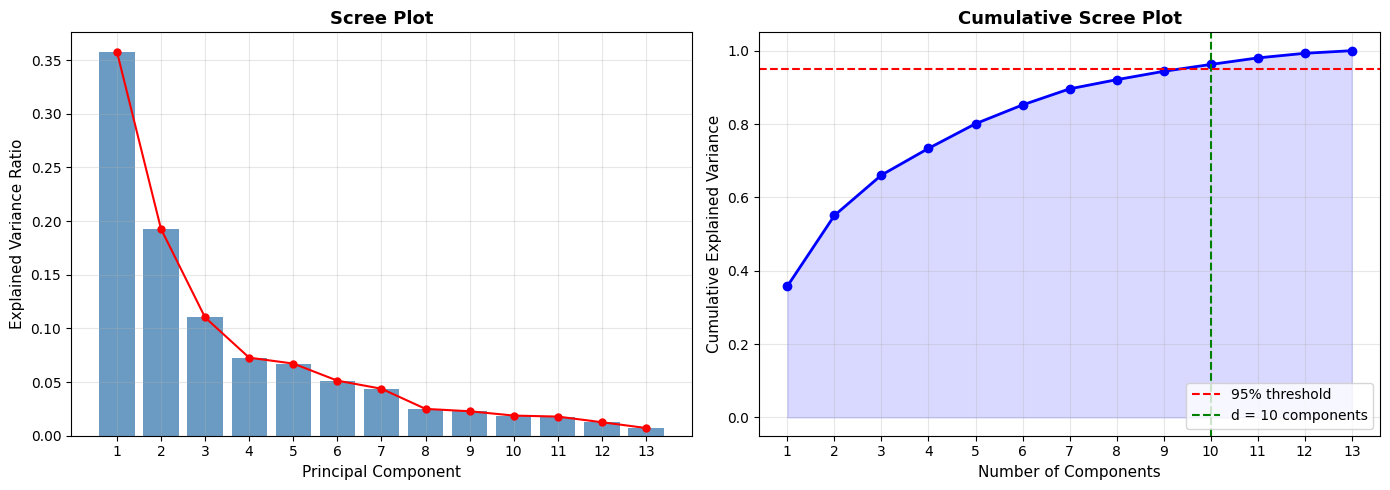

Scree plots saved as 'assignment1_images/scree_plots.png'



In [11]:
# ============================================================
# 步骤 8：可视化 - Scree Plot和累积Scree Plot
# Step 8: Visualization - Scree Plot and Cumulative Scree Plot
# ============================================================
print("=" * LINE_WIDTH)
print("Step 8: Scree Plot and Cumulative Scree Plot")
print("=" * LINE_WIDTH)

# 创建2个子图（1行2列）：Scree Plot 和 Cumulative Scree Plot
# Create 2 subplots (1 row, 2 columns): Scree Plot and Cumulative Scree Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 组件序号
# Component indices
components = range(1, len(explained_var) + 1)

# 子图1：Scree Plot（单独方差）
# Subplot 1: Scree Plot (individual variance)
ax1.bar(components, explained_var, color='steelblue', alpha=0.8)
ax1.plot(components, explained_var, 'ro-', markersize=5)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11)
ax1.set_title('Scree Plot', fontsize=13, fontweight='bold')
ax1.set_xticks(list(components))
ax1.grid(True, alpha=0.3)

# 子图2：Cumulative Scree Plot（累积方差）
# Subplot 2: Cumulative Scree Plot (cumulative variance)
ax2.plot(components, cumulative_var, 'bo-', markersize=6, linewidth=2)
ax2.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--',
            label=f'{VARIANCE_THRESHOLD*100:.0f}% threshold')
ax2.axvline(x=d_pca, color='g', linestyle='--',
            label=f'd = {d_pca} components')
ax2.fill_between(components, cumulative_var, alpha=0.15, color='blue')
ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax2.set_title('Cumulative Scree Plot', fontsize=13, fontweight='bold')
ax2.set_xticks(list(components))
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scree_plots.png', dpi=IMAGE_DPI, bbox_inches='tight')
plt.show()

print("Scree plots saved as 'assignment1_images/scree_plots.png'")
print()

In [12]:
# ============================================================
# 步骤 9：建模与评估 - 定义分类函数
# Step 9: Modeling & Evaluation - Define Classification Function
# ============================================================
print("=" * LINE_WIDTH)
print("Step 9: Define classification function")
print("=" * LINE_WIDTH)


# ============================================================
# classify_and_evaluate: 对数据集使用指定的分类器进行训练和评估
#                        Train and evaluate a classifier on the given dataset
#
# Parameters:
#   X_tr: 训练集特征
#         Training set features
#   X_te: 测试集特征
#         Test set features
#   y_tr: 训练集标签
#         Training set labels
#   y_te: 测试集标签
#         Test set labels
#   clf: 分类器实例
#        Classifier instance
#   clf_name: 分类器名称
#             Classifier name
#   params_desc: 参数描述
#                Parameters description
#
# Returns:
#   dict: 包含方法名、参数、准确率、F1分数的字典
#         Dictionary with method name, parameters, accuracy, F1 score
# ============================================================
def classify_and_evaluate(X_tr, X_te, y_tr, y_te, clf, clf_name, params_desc):
    """对数据集使用指定的分类器进行训练和评估
    Train and evaluate a classifier on the given dataset"""

    # 训练分类器
    # Train classifier
    clf.fit(X_tr, y_tr)

    # 预测
    # Predict
    y_pred = clf.predict(X_te)

    # 计算准确率
    # Calculate accuracy
    acc = accuracy_score(y_te, y_pred)

    # 计算加权F1分数（多分类使用加权平均）
    # Calculate weighted F1 score (use weighted average for multi-class)
    f1 = f1_score(y_te, y_pred, average='weighted')

    return {
        'method': clf_name,
        'params': params_desc,
        'accuracy': acc,
        'f1_score': f1,
        'model': clf
    }


print("Classification function defined.")
print()

Step 9: Define classification function
Classification function defined.



In [13]:
# ============================================================
# 步骤 10：建模与评估 - 在三个数据集上运行五种分类器
# Step 10: Modeling & Evaluation - Run 5 Classifiers on 3 Datasets
# ============================================================
print("=" * LINE_WIDTH)
print("Step 10: Run 5 classifiers x 3 parameter sets x 3 datasets")
print("=" * LINE_WIDTH)

# 定义三个数据集
# Define three datasets
datasets = {
    'Standardized': (X_train_scaled, X_test_scaled),
    'After PCA': (X_train_pca, X_test_pca),
    'After LDA': (X_train_lda, X_test_lda)
}

# ================================================================
# 分类器 1：kNN（k近邻）
# Classifier 1: kNN (k-Nearest Neighbors)
# ================================================================
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   根据最近的k个邻居的多数类别进行预测
#   Predict based on majority class of k nearest neighbors
#
# 公式 / Formula:
#   距离度量：d(x, x') = sqrt(Σ(x_i - x'_i)²) (欧几里得距离)
#
# 举例 / Example:
#   k=5时，找到5个最近邻居，3个属于A类，2个属于B类 → 预测为A类
#
# 优点 / Advantages:
#   - 简单直观，无需训练过程
#   - 非线性决策边界
# ================================================================

# 三组kNN参数配置
# Three sets of kNN parameter configurations
knn_configs = [
    # k=3: 小k捕捉局部模式，可能对噪声敏感；uniform=等权投票；euclidean=欧式距离
    # k=3: Small k captures local patterns, may be noise-sensitive; uniform=equal vote; euclidean distance
    (KNeighborsClassifier(n_neighbors=3, weights='uniform', metric='euclidean'),
     "k=3, weights=uniform, metric=euclidean"),
    # k=5: 适中k平衡局部与全局；distance=近邻权重更大，减少异常值影响
    # k=5: Moderate k balances local/global; distance=closer neighbors weighted more, reduces outlier effect
    (KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean'),
     "k=5, weights=distance, metric=euclidean"),
    # k=7: 较大k更平滑稳健；manhattan=曼哈顿距离（绝对差之和），对异常值更鲁棒
    # k=7: Larger k gives smoother boundaries; manhattan=sum of absolute differences, more robust to outliers
    (KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'),
     "k=7, weights=distance, metric=manhattan"),
]

# ================================================================
# 分类器 2：Random Forest（随机森林）
# Classifier 2: Random Forest
# ================================================================
#
# -------- 术语解释 / Terminology --------
#
# 【决策树 Decision Tree】
#   通过特征条件分裂递归地划分数据
#   Recursively partition data by feature conditions
#
# 【Bagging 装袋法】
#   对数据进行有放回采样，训练多棵树，取多数投票
#   Bootstrap sampling with replacement, train multiple trees, take majority vote
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   由多棵决策树组成的集成学习方法，每棵树用随机子集训练
#   Ensemble of decision trees, each trained on random subsets
#
# 公式 / Formula:
#   预测 = mode(tree_1(x), tree_2(x), ..., tree_n(x))
#
# 举例 / Example:
#   100棵树中，60棵预测A类，40棵预测B类 → 最终预测A类
#
# 优点 / Advantages:
#   - 减少过拟合（相比单棵决策树）
#   - 可处理高维数据，不需要特征缩放
# ================================================================

# 三组RF参数配置
# Three sets of RF parameter configurations
rf_configs = [
    # 50棵树，无深度限制：树完全生长直到叶子纯净，灵活性高
    # 50 trees, no depth limit: trees grow fully until pure leaves, high flexibility
    (RandomForestClassifier(n_estimators=50, max_depth=None, random_state=RANDOM_STATE),
     "n_estimators=50, max_depth=None"),
    # 100棵树，最大深度10：限制树复杂度，防止过拟合
    # 100 trees, max depth 10: limits tree complexity, prevents overfitting
    (RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE),
     "n_estimators=100, max_depth=10"),
    # 200棵树，深度20，最少5样本才分裂：更多树+正则化，平衡复杂度与泛化
    # 200 trees, depth 20, min 5 samples to split: more trees + regularization, balances complexity and generalization
    (RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=RANDOM_STATE),
     "n_estimators=200, max_depth=20, min_samples_split=5"),
]

# ================================================================
# 分类器 3：SVM（支持向量机）
# Classifier 3: SVM (Support Vector Machine)
# ================================================================
#
# -------- 术语解释 / Terminology --------
#
# 【超平面 Hyperplane】
#   在高维空间中分隔不同类别的决策面
#   Decision surface separating different classes in high-dimensional space
#
# 【支持向量 Support Vectors】
#   距离超平面最近的数据点，决定了超平面的位置
#   Data points closest to the hyperplane, determine its position
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   找到最大间隔的超平面来分隔不同类别
#   Find the hyperplane with maximum margin to separate classes
#
# 公式 / Formula:
#   最大化间隔：max 2/||w||，约束：y_i(w·x_i + b) >= 1
#
# 举例 / Example:
#   2D数据中放一条直线分开两类点，让直线到最近点的距离最大
#
# 优点 / Advantages:
#   - 在高维空间中表现优秀
#   - 核技巧可处理非线性问题
# ================================================================

# 三组SVM参数配置
# Three sets of SVM parameter configurations
svm_configs = [
    # 线性核，C=1.0（默认正则化）：用超平面分隔类别，适合线性可分数据
    # Linear kernel, C=1.0 (default regularization): separates classes with hyperplane, suits linearly separable data
    (SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE),
     "kernel=linear, C=1.0"),
    # RBF核，gamma=scale（γ=1/(n_features×var)）：映射到高维空间实现非线性分隔
    # RBF kernel, gamma=scale (γ=1/(n_features×var)): maps to higher-dim space for non-linear separation
    (SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
     "kernel=rbf, C=1.0, gamma=scale"),
    # 多项式核degree=3，C=10.0（更严格惩罚误分类）：创建弯曲决策边界
    # Polynomial kernel degree=3, C=10.0 (stricter misclassification penalty): creates curved decision boundaries
    (SVC(kernel='poly', C=10.0, degree=3, random_state=RANDOM_STATE),
     "kernel=poly, C=10.0, degree=3"),
]

# ================================================================
# 分类器 4：Logistic Regression（逻辑回归）
# Classifier 4: Logistic Regression
# ================================================================
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   通过sigmoid/softmax将线性输出映射到概率分布
#   Map linear output to probability distribution via sigmoid/softmax
#
# 公式 / Formula:
#   多分类：P(y=k|x) = e^(w_k·x) / Σ e^(w_j·x) (softmax)
#
# 举例 / Example:
#   输出 z=[2.0, 1.0, 0.1] → softmax=[0.659, 0.242, 0.099] → 预测类0
#
# 优点 / Advantages:
#   - 输出概率值，可解释性强
#   - 训练速度快，适合大规模数据
# ================================================================

# 三组LR参数配置
# Three sets of LR parameter configurations
# max_iter=5000 确保收敛
# max_iter=5000 ensures convergence
lr_configs = [
    # C=0.1: 强正则化，减少过拟合风险；lbfgs求解器适合多分类+L2惩罚
    # C=0.1: Strong regularization, reduces overfitting risk; lbfgs solver suits multi-class + L2 penalty
    (LogisticRegression(C=0.1, solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE),
     "C=0.1, solver=lbfgs"),
    # C=1.0: 默认正则化强度，偏差与方差的平衡点
    # C=1.0: Default regularization strength, balance point between bias and variance
    (LogisticRegression(C=1.0, solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE),
     "C=1.0, solver=lbfgs"),
    # C=10.0: 弱正则化，允许模型更自由拟合训练数据，可能增加方差
    # C=10.0: Weak regularization, allows model to fit training data more freely, may increase variance
    (LogisticRegression(C=10.0, solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE),
     "C=10.0, solver=lbfgs"),
]

# ================================================================
# 分类器 5：MLP（多层感知器）
# Classifier 5: MLP (Multi-Layer Perceptron)
# ================================================================
#
# -------- 术语解释 / Terminology --------
#
# 【隐藏层 Hidden Layers】
#   输入层和输出层之间的神经元层
#   Layers of neurons between input and output layers
#
# 【激活函数 Activation Function】
#   引入非线性的函数，如ReLU: f(x) = max(0, x)
#   Function that introduces non-linearity, e.g., ReLU: f(x) = max(0, x)
#
# -------- 算法原理 / Algorithm --------
#
# 定义 / Definition:
#   由多层神经元组成的前馈神经网络，通过反向传播学习
#   Feed-forward neural network with multiple layers, learns via backpropagation
#
# 公式 / Formula:
#   输出 = activation(W_L * ... * activation(W_2 * activation(W_1 * x + b_1) + b_2) ... + b_L)
#
# 举例 / Example:
#   hidden_layer_sizes=(100,50) 表示2个隐藏层，第一层100个神经元，第二层50个
#
# 优点 / Advantages:
#   - 可以学习复杂的非线性模式
#   - 通用近似器，理论上可拟合任何函数
# ================================================================

# 三组MLP参数配置
# Three sets of MLP parameter configurations
mlp_configs = [
    # 单隐藏层50神经元，ReLU激活：简单架构，适合小数据集
    # Single hidden layer with 50 neurons, ReLU activation: simple architecture for small datasets
    (MLPClassifier(hidden_layer_sizes=(50,), activation='relu', max_iter=1000, random_state=RANDOM_STATE),
     "hidden=(50,), activation=relu"),
    # 两隐藏层(100→50)，ReLU：更深架构可捕捉更复杂模式
    # Two hidden layers (100→50), ReLU: deeper architecture captures more complex patterns
    (MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=1000, random_state=RANDOM_STATE),
     "hidden=(100,50), activation=relu"),
    # 两隐藏层(100→100)，tanh激活（输出[-1,1]）：tanh在某些情况下梯度传播更好
    # Two hidden layers (100→100), tanh activation (output [-1,1]): tanh can improve gradient flow in some cases
    (MLPClassifier(hidden_layer_sizes=(100, 100), activation='tanh', max_iter=1000, random_state=RANDOM_STATE),
     "hidden=(100,100), activation=tanh"),
]

# 将所有分类器配置合并
# Combine all classifier configurations
all_classifiers = {
    'kNN': knn_configs,
    'RF': rf_configs,
    'SVM': svm_configs,
    'LR': lr_configs,
    'MLP': mlp_configs
}

# 存储所有结果
# Store all results
# 结构：{dataset_name: {method_name: [result1, result2, result3]}}
# Structure: {dataset_name: {method_name: [result1, result2, result3]}}
all_results = {}

# 遍历每个数据集
# Iterate over each dataset
for ds_name, (X_tr, X_te) in datasets.items():
    print(f"\n--- Dataset: {ds_name} ---")
    all_results[ds_name] = {}

    # 遍历每种分类器
    # Iterate over each classifier
    for clf_name, configs in all_classifiers.items():
        all_results[ds_name][clf_name] = []

        # 遍历每组参数
        # Iterate over each parameter set
        for clf, params_desc in configs:
            result = classify_and_evaluate(
                X_tr, X_te, y_train, y_test,
                clf, clf_name, params_desc
            )
            all_results[ds_name][clf_name].append(result)
            print(f"  {clf_name} ({params_desc}): Acc={result['accuracy']:.4f}, F1={result['f1_score']:.4f}")

print()

Step 10: Run 5 classifiers x 3 parameter sets x 3 datasets

--- Dataset: Standardized ---
  kNN (k=3, weights=uniform, metric=euclidean): Acc=0.9722, F1=0.9723
  kNN (k=5, weights=distance, metric=euclidean): Acc=0.9722, F1=0.9724
  kNN (k=7, weights=distance, metric=manhattan): Acc=1.0000, F1=1.0000
  RF (n_estimators=50, max_depth=None): Acc=1.0000, F1=1.0000
  RF (n_estimators=100, max_depth=10): Acc=1.0000, F1=1.0000
  RF (n_estimators=200, max_depth=20, min_samples_split=5): Acc=1.0000, F1=1.0000
  SVM (kernel=linear, C=1.0): Acc=0.9444, F1=0.9443
  SVM (kernel=rbf, C=1.0, gamma=scale): Acc=0.9722, F1=0.9720
  SVM (kernel=poly, C=10.0, degree=3): Acc=0.9167, F1=0.9156
  LR (C=0.1, solver=lbfgs): Acc=1.0000, F1=1.0000
  LR (C=1.0, solver=lbfgs): Acc=0.9722, F1=0.9720
  LR (C=10.0, solver=lbfgs): Acc=0.9722, F1=0.9720
  MLP (hidden=(50,), activation=relu): Acc=0.9444, F1=0.9443
  MLP (hidden=(100,50), activation=relu): Acc=1.0000, F1=1.0000
  MLP (hidden=(100,100), activation=tanh):

In [14]:
# ============================================================
# 步骤 11：结果汇总 - 最佳结果表格
# Step 11: Results Summary - Best Results Table
# ============================================================
print("=" * LINE_WIDTH)
print("Step 11: Best results table (Accuracy & F1)")
print("=" * LINE_WIDTH)

# 构建结果表格
# Build results table
table_data = []
method_order = ['kNN', 'RF', 'SVM', 'LR', 'MLP']

for method in method_order:
    # 找到每个数据集上该方法的最佳结果
    # Find the best result for this method on each dataset
    best_std = max(all_results['Standardized'][method], key=lambda x: x['accuracy'])
    best_pca = max(all_results['After PCA'][method], key=lambda x: x['accuracy'])
    best_lda = max(all_results['After LDA'][method], key=lambda x: x['accuracy'])

    table_data.append([
        method,
        best_std['params'],
        f"{best_std['accuracy']:.4f}",
        f"{best_std['f1_score']:.4f}",
        f"{best_pca['accuracy']:.4f}",
        f"{best_pca['f1_score']:.4f}",
        f"{best_lda['accuracy']:.4f}",
        f"{best_lda['f1_score']:.4f}",
    ])

# 打印汇总表格
# Print summary table
headers = ['Method', 'Best Parameters', 'Std Acc', 'Std F1', 'PCA Acc', 'PCA F1', 'LDA Acc', 'LDA F1']
print(tabulate(table_data, headers=headers, tablefmt='grid'))
print()

Step 11: Best results table (Accuracy & F1)
+----------+-----------------------------------------+-----------+----------+-----------+----------+-----------+----------+
| Method   | Best Parameters                         |   Std Acc |   Std F1 |   PCA Acc |   PCA F1 |   LDA Acc |   LDA F1 |
+==========+=========================================+===========+==========+===========+==========+===========+==========+
| kNN      | k=7, weights=distance, metric=manhattan |    1      |    1     |    0.9722 |   0.9724 |    0.9722 |    0.972 |
+----------+-----------------------------------------+-----------+----------+-----------+----------+-----------+----------+
| RF       | n_estimators=50, max_depth=None         |    1      |    1     |    0.9444 |   0.9444 |    0.9722 |    0.972 |
+----------+-----------------------------------------+-----------+----------+-----------+----------+-----------+----------+
| SVM      | kernel=rbf, C=1.0, gamma=scale          |    0.9722 |    0.972 |    0.9722 

In [15]:
# ============================================================
# 步骤 12：详细结果表格 - 所有参数组合
# Step 12: Detailed Results - All Parameter Combinations
# ============================================================
print("=" * LINE_WIDTH)
print("Step 12: Detailed results for all parameter combinations")
print("=" * LINE_WIDTH)

# 构建详细表格
# Build detailed table
detail_data = []

for method in method_order:
    for i in range(3):
        std_result = all_results['Standardized'][method][i]
        pca_result = all_results['After PCA'][method][i]
        lda_result = all_results['After LDA'][method][i]

        detail_data.append([
            method,
            std_result['params'],
            f"{std_result['accuracy']:.4f}",
            f"{std_result['f1_score']:.4f}",
            f"{pca_result['accuracy']:.4f}",
            f"{pca_result['f1_score']:.4f}",
            f"{lda_result['accuracy']:.4f}",
            f"{lda_result['f1_score']:.4f}",
        ])

# 打印详细表格
# Print detailed table
detail_headers = ['Method', 'Parameters', 'Std Acc', 'Std F1', 'PCA Acc', 'PCA F1', 'LDA Acc', 'LDA F1']
print(tabulate(detail_data, headers=detail_headers, tablefmt='grid'))
print()

Step 12: Detailed results for all parameter combinations
+----------+-----------------------------------------------------+-----------+----------+-----------+----------+-----------+----------+
| Method   | Parameters                                          |   Std Acc |   Std F1 |   PCA Acc |   PCA F1 |   LDA Acc |   LDA F1 |
+==========+=====================================================+===========+==========+===========+==========+===========+==========+
| kNN      | k=3, weights=uniform, metric=euclidean              |    0.9722 |   0.9723 |    0.9444 |   0.9435 |    0.9444 |   0.9443 |
+----------+-----------------------------------------------------+-----------+----------+-----------+----------+-----------+----------+
| kNN      | k=5, weights=distance, metric=euclidean             |    0.9722 |   0.9724 |    0.9722 |   0.9724 |    0.9444 |   0.9443 |
+----------+-----------------------------------------------------+-----------+----------+-----------+----------+-----------+---

Step 13: PCA 2D visualization with support vectors


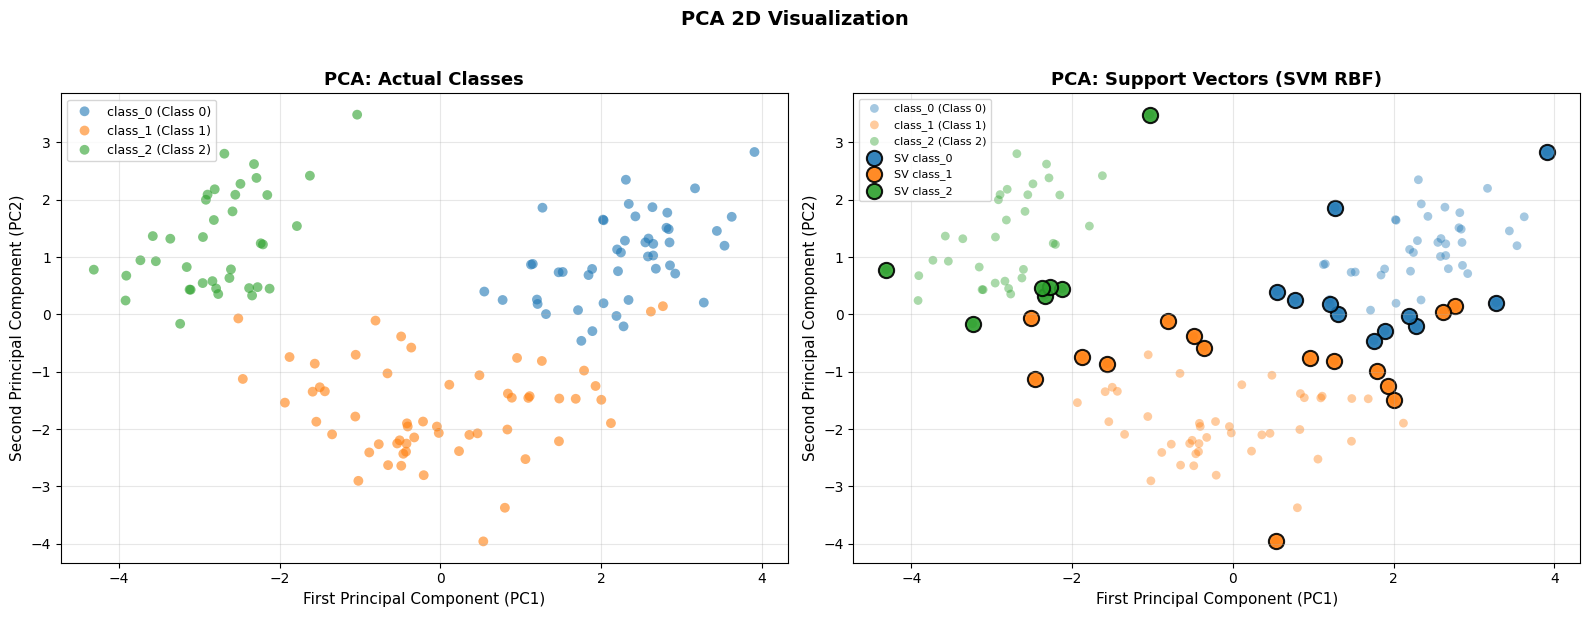

PCA 2D plot saved as 'assignment1_images/pca_2d_svm.png'



In [16]:
# ============================================================
# 步骤 13：可视化 - PCA 2D散点图（含支持向量）
# Step 13: Visualization - PCA 2D Scatter with Support Vectors
# ============================================================
print("=" * LINE_WIDTH)
print("Step 13: PCA 2D visualization with support vectors")
print("=" * LINE_WIDTH)

# 为2D可视化使用前2个主成分
# Use first 2 principal components for 2D visualization
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

# 在2D PCA数据上训练SVM（使用rbf核）用于获取支持向量
# Train SVM on 2D PCA data (using rbf kernel) to get support vectors
svm_pca_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_pca_2d.fit(X_train_pca_2d, y_train)

# 获取支持向量
# Get support vectors
support_vectors_pca = svm_pca_2d.support_vectors_
support_vector_indices_pca = svm_pca_2d.support_
support_vector_labels_pca = y_train[support_vector_indices_pca]

# 创建2个并排的子图
# Create 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 定义类别颜色
# Define class colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = list(wine.target_names)

# 子图1：PCA训练集，按实际类别颜色编码
# Subplot 1: PCA training set, color-coded by actual class
for cls in range(n_classes):
    mask = y_train == cls
    ax1.scatter(X_train_pca_2d[mask, 0], X_train_pca_2d[mask, 1],
                c=colors[cls], label=f'{class_names[cls]} (Class {cls})',
                alpha=0.6, s=50, edgecolors='none')

ax1.set_xlabel('First Principal Component (PC1)', fontsize=11)
ax1.set_ylabel('Second Principal Component (PC2)', fontsize=11)
ax1.set_title('PCA: Actual Classes', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 子图2：PCA训练集 + 支持向量
# Subplot 2: PCA training set + support vectors
for cls in range(n_classes):
    mask = y_train == cls
    ax2.scatter(X_train_pca_2d[mask, 0], X_train_pca_2d[mask, 1],
                c=colors[cls], label=f'{class_names[cls]} (Class {cls})',
                alpha=0.4, s=40, edgecolors='none')

# 绘制支持向量（用black边框标注）
# Plot support vectors (marked with black edge)
for cls in range(n_classes):
    sv_mask = support_vector_labels_pca == cls
    if np.any(sv_mask):
        ax2.scatter(support_vectors_pca[sv_mask, 0], support_vectors_pca[sv_mask, 1],
                    c=colors[cls], edgecolors='black',
                    label=f'SV {class_names[cls]}',
                    s=120, linewidths=1.5, marker='o', alpha=0.9)

ax2.set_xlabel('First Principal Component (PC1)', fontsize=11)
ax2.set_ylabel('Second Principal Component (PC2)', fontsize=11)
ax2.set_title('PCA: Support Vectors (SVM RBF)', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('PCA 2D Visualization', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_2d_svm.png', dpi=IMAGE_DPI, bbox_inches='tight')
plt.show()

print("PCA 2D plot saved as 'assignment1_images/pca_2d_svm.png'")
print()

Step 14: LDA 2D visualization with support vectors


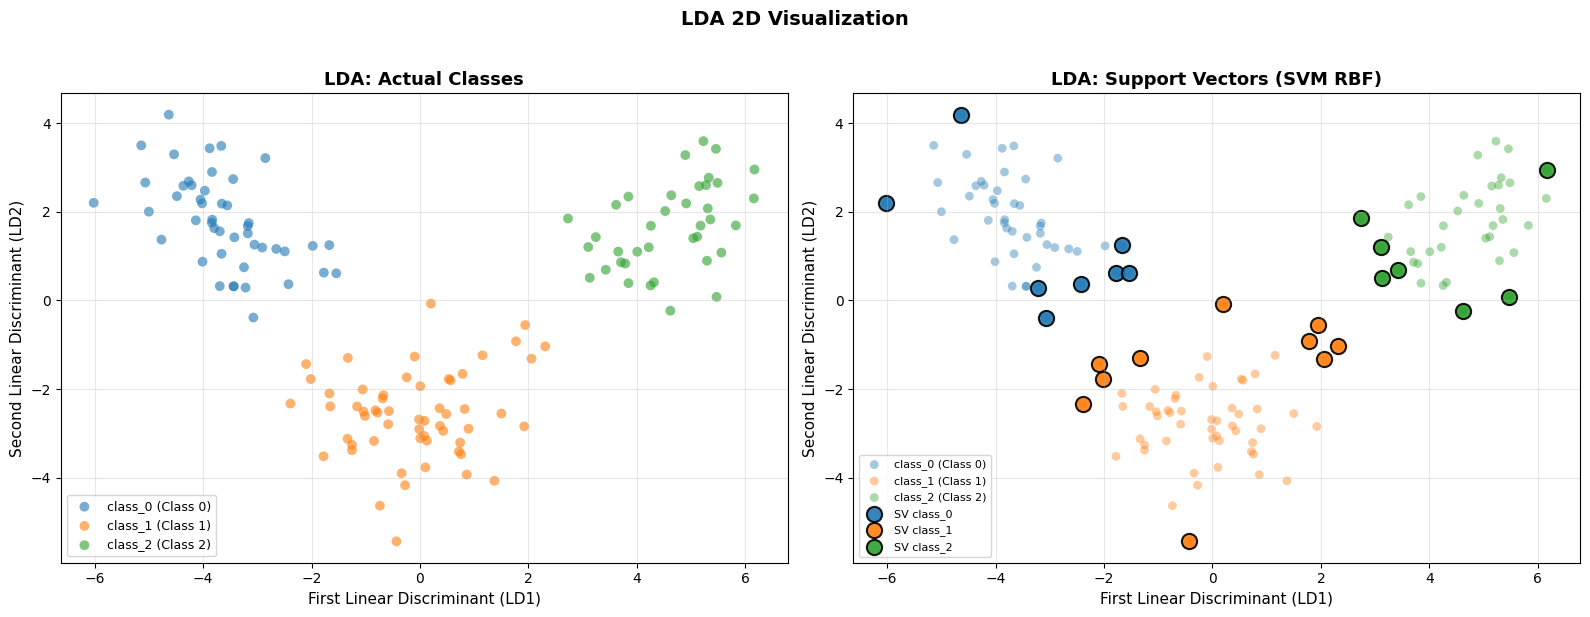

LDA 2D plot saved as 'assignment1_images/lda_2d_svm.png'



In [17]:
# ============================================================
# 步骤 14：可视化 - LDA 2D散点图（含支持向量）
# Step 14: Visualization - LDA 2D Scatter with Support Vectors
# ============================================================
print("=" * LINE_WIDTH)
print("Step 14: LDA 2D visualization with support vectors")
print("=" * LINE_WIDTH)

# LDA已经是2D的（因为只有2个成分）
# LDA is already 2D (since only 2 components)
# 在LDA数据上训练SVM用于获取支持向量
# Train SVM on LDA data to get support vectors
svm_lda_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_lda_2d.fit(X_train_lda, y_train)

# 获取支持向量
# Get support vectors
support_vectors_lda = svm_lda_2d.support_vectors_
support_vector_indices_lda = svm_lda_2d.support_
support_vector_labels_lda = y_train[support_vector_indices_lda]

# 创建2个并排的子图
# Create 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 子图1：LDA训练集，按实际类别颜色编码
# Subplot 1: LDA training set, color-coded by actual class
for cls in range(n_classes):
    mask = y_train == cls
    ax1.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
                c=colors[cls], label=f'{class_names[cls]} (Class {cls})',
                alpha=0.6, s=50, edgecolors='none')

ax1.set_xlabel('First Linear Discriminant (LD1)', fontsize=11)
ax1.set_ylabel('Second Linear Discriminant (LD2)', fontsize=11)
ax1.set_title('LDA: Actual Classes', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 子图2：LDA训练集 + 支持向量
# Subplot 2: LDA training set + support vectors
for cls in range(n_classes):
    mask = y_train == cls
    ax2.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1],
                c=colors[cls], label=f'{class_names[cls]} (Class {cls})',
                alpha=0.4, s=40, edgecolors='none')

# 绘制支持向量
# Plot support vectors
for cls in range(n_classes):
    sv_mask = support_vector_labels_lda == cls
    if np.any(sv_mask):
        ax2.scatter(support_vectors_lda[sv_mask, 0], support_vectors_lda[sv_mask, 1],
                    c=colors[cls], edgecolors='black',
                    label=f'SV {class_names[cls]}',
                    s=120, linewidths=1.5, marker='o', alpha=0.9)

ax2.set_xlabel('First Linear Discriminant (LD1)', fontsize=11)
ax2.set_ylabel('Second Linear Discriminant (LD2)', fontsize=11)
ax2.set_title('LDA: Support Vectors (SVM RBF)', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA 2D Visualization', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lda_2d_svm.png', dpi=IMAGE_DPI, bbox_inches='tight')
plt.show()

print("LDA 2D plot saved as 'assignment1_images/lda_2d_svm.png'")
print()